# Phase 8

**Goal:** check whether the model catches every money-laundering *pattern type*
(FAN-OUT, CYCLE, STACK, ...) equally well, or whether it silently misses
specific typologies while acing others.

This section reuses the model and predictions already produced in
`03_baseline_model_mlflow.ipynb` — no retraining, no new predictions.
It only adds a new lens for looking at results that already exist:
`HI-Small_Patterns.txt` labels which laundering transactions belong to
which pattern type, something `HI-Small_Trans.csv` alone does not tell us.

**Structure of this notebook:**
1. Parse `HI-Small_Patterns.txt` into a tidy table
2. Match those rows back into `HI-Small_Trans.csv` to tag each laundering
   transaction with its pattern type
3. Join with the model's saved test-set predictions and compute recall
   per pattern type


## Section 1 — # Track C: Typology Breakdown
Parse `HI-Small_Patterns.txt`

In [1]:
import re
from pathlib import Path
from sklearn.metrics import confusion_matrix
import pandas as pd
from pathlib import Path
import pandas as pd

pd.set_option("display.max_columns", None)

### 1.1 — Read the raw file

`HI-Small_Patterns.txt` is plain text, not CSV. It is organised in blocks:

```
BEGIN LAUNDERING ATTEMPT - <PATTERN_TYPE>: <optional detail>
<transaction line 1>
<transaction line 2>
...
END LAUNDERING ATTEMPT - <PATTERN_TYPE>
```

Read it first as a plain list of lines and confirm it looks as expected
before writing any parsing logic against it.


In [2]:
PATTERNS_PATH = Path("../data/HI-Small_Patterns.txt")

with open(PATTERNS_PATH, "r") as f:
    raw_lines = f.readlines()

print(f"Total lines in file: {len(raw_lines):,}")
print("--- First 5 lines ---")
for line in raw_lines[:5]:
    print(line.strip())


Total lines in file: 4,319
--- First 5 lines ---
BEGIN LAUNDERING ATTEMPT - FAN-OUT:  Max 16-degree Fan-Out
2022/09/01 00:06,021174,800737690,012,80011F990,2848.96,Euro,2848.96,Euro,ACH,1
2022/09/01 04:33,021174,800737690,020,80020C5B0,8630.40,Euro,8630.40,Euro,ACH,1
2022/09/01 09:14,021174,800737690,020,80006A5E0,35642.49,Yuan,35642.49,Yuan,ACH,1
2022/09/01 09:56,021174,800737690,00220,8007A5B70,5738987.96,US Dollar,5738987.96,US Dollar,ACH,1


### 1.2 — Parse into a tidy DataFrame

Each transaction line inside a block has 11 comma-separated fields,
matching the standard IBM AML transaction schema (the same schema used
in `*_Trans.csv`). The parser below is a small state machine: it tracks
which pattern type block it is currently inside, and tags every
transaction line it encounters with that pattern type.

It deliberately raises an error instead of silently skipping malformed
lines — a parser that fails loudly on unexpected input is safer than
one that quietly drops or mislabels rows.


### 1.2a — Data dictionary

Before parsing, it's worth having a single reference for what every
column actually means — both the raw columns that come straight from
the IBM AML schema, and the two columns this notebook engineers on
top of them.

| Column | Type | Meaning |
|---|---|---|
| `Timestamp` | datetime string | Date and time the transaction was initiated (`YYYY/MM/DD HH:MM`) |
| `From Bank` | categorical code | Numeric ID of the bank the money left from |
| `From Account` | categorical code | Account number at the sending bank |
| `To Bank` | categorical code | Numeric ID of the bank the money arrived at |
| `To Account` | categorical code | Account number at the receiving bank |
| `Amount Paid` | float | Amount debited from the sender, in `Payment Currency` |
| `Payment Currency` | categorical | Currency the sender's side of the transaction is denominated in |
| `Amount Received` | float | Amount credited to the receiver, in `Receiving Currency` |
| `Receiving Currency` | categorical | Currency the receiver's side of the transaction is denominated in |
| `Payment Format` | categorical | The rail used to move the money — ACH, Wire, Cheque, Credit Card, Cash, Bitcoin, Reinvestment |
| `Is Laundering` | binary flag | `1` if this transaction is part of a labelled laundering scheme, else `0`. Always `1` inside `Patterns.txt`, since that file only lists laundering transactions |
| `pattern_type` *(engineered)* | categorical | Added by the parser below; identifies which of the 8 laundering typologies (see 1.2b) this transaction belongs to |
| `match_key` *(engineered)* | string | Added later in 1.3; concatenates every identifying column so a `Patterns.txt` row can be matched back to its `Trans.csv` row — neither file has a standalone transaction ID |

**One subtlety worth flagging:** `Amount Paid` and `Amount Received` can
differ even for a single transaction whenever `Payment Currency` and
`Receiving Currency` differ — the gap reflects a currency conversion,
not an error in the data.


In [3]:
# Column names match the standard IBM AML transaction schema, used
# consistently across Patterns.txt and *_Trans.csv files.
TRANSACTION_COLUMNS = [
    "Timestamp",
    "From Bank",
    "From Account",
    "To Bank",
    "To Account",
    "Amount Received",
    "Receiving Currency",
    "Amount Paid",
    "Payment Currency",
    "Payment Format",
    "Is Laundering",
]

BEGIN_RE = re.compile(r"^BEGIN LAUNDERING ATTEMPT - ([A-Z\-]+)")
END_RE = re.compile(r"^END LAUNDERING ATTEMPT")


def parse_patterns_file(lines: list[str]) -> pd.DataFrame:
    """
    Parse an IBM AML *_Patterns.txt file into a tidy DataFrame with one
    row per laundering transaction, tagged with its `pattern_type`.
    """
    records = []
    current_pattern = None

    for raw_line in lines:
        line = raw_line.strip()
        if not line:
            continue

        begin_match = BEGIN_RE.match(line)
        if begin_match:
            current_pattern = begin_match.group(1)
            continue

        if END_RE.match(line):
            current_pattern = None
            continue

        # Anything else should be a transaction row.
        if current_pattern is None:
            raise ValueError(
                f"Transaction line found outside any BEGIN/END block: {line!r}"
            )

        fields = line.split(",")
        if len(fields) != len(TRANSACTION_COLUMNS):
            raise ValueError(
                f"Expected {len(TRANSACTION_COLUMNS)} fields, got {len(fields)}: {line!r}"
            )

        record = dict(zip(TRANSACTION_COLUMNS, fields))
        record["pattern_type"] = current_pattern
        records.append(record)

    return pd.DataFrame.from_records(records)


patterns_df = parse_patterns_file(raw_lines)

print(f"Parsed {len(patterns_df):,} laundering transactions")
print(f"Pattern types found: {sorted(patterns_df['pattern_type'].unique())}")
patterns_df["pattern_type"].value_counts()


Parsed 3,209 laundering transactions
Pattern types found: ['BIPARTITE', 'CYCLE', 'FAN-IN', 'FAN-OUT', 'GATHER-SCATTER', 'RANDOM', 'SCATTER-GATHER', 'STACK']


pattern_type
GATHER-SCATTER    716
SCATTER-GATHER    626
STACK             466
FAN-OUT           342
FAN-IN            318
CYCLE             287
BIPARTITE         263
RANDOM            191
Name: count, dtype: int64

### 1.2b — What each of the 8 laundering pattern types means

The cell above confirmed all 8 documented AML typologies are present in
this file. Each one describes a different *shape* of money movement
between accounts — worth understanding before matching or modelling
against them, since a model that is good at spotting one shape may be
structurally blind to another.

A classic way to think about money laundering is in three stages —
**placement** (getting illicit cash into the financial system),
**layering** (moving it through many transactions to obscure its
origin), and **integration** (returning it to the criminal looking
legitimate). Most of the 8 patterns below are layering techniques —
they exist specifically to break the paper trail between where money
started and where it ends up.

- **FAN-OUT** — one account sends money out to many different accounts.
  A single account splits a large sum into many smaller outgoing
  transfers, making each individual payment look unremarkable
  (structuring). The `Max N-degree Fan-Out` annotation in the raw file
  is the number of distinct accounts that one source paid into.

- **FAN-IN** — the mirror image of FAN-OUT: many different accounts all
  send money into one account. Used to collect many smaller amounts
  from multiple sources into a single account before moving it onward.
  `Max N-degree Fan-In` is the number of distinct accounts that fed
  into that one destination.

- **CYCLE** — money moves through a chain of accounts and eventually
  comes back to the account it started from. Creates the appearance of
  trading activity between unrelated parties, while the funds are
  simply circulating among accounts the same actor controls.
  `Max N hops` is the number of accounts the money passed through
  before returning to its origin.

- **RANDOM** — a chain of transfers similar to CYCLE, but the money
  never loops back to where it started. Closer to an unstructured walk
  between accounts, and deliberately avoids the circular signature that
  makes CYCLE easier to flag.

- **GATHER-SCATTER** — a FAN-IN into an account, immediately followed
  by a FAN-OUT from that *same* account. Funds are gathered in from
  many sources, then immediately redistributed out to many
  destinations — a "layering hub" whose only role is to mix and
  re-route money quickly.

- **SCATTER-GATHER** — the reverse ordering: money fans out from one
  source to a set of intermediate accounts, and those same
  intermediaries then all funnel their funds into a single destination.
  Routes money through several throwaway accounts before reuniting it.

- **BIPARTITE** — a set of "input" accounts all send money to a set of
  "output" accounts, many-to-many, without any single account acting as
  an obvious hub. Often the simplest layering structure — spreading
  transfers across a group on each side to dilute the signal.

- **STACK** — extends BIPARTITE by adding one more layer of accounts in
  between: money moves from group A, through group B, to group C. One
  extra hop of obfuscation stacked on top of a plain many-to-many
  transfer.

Two structural groups are worth keeping in mind going into Section 3:
FAN-IN/FAN-OUT/BIPARTITE/STACK are built from very regular,
one-directional flows (easier to imagine a model learning to spot),
while CYCLE/RANDOM/GATHER-SCATTER/SCATTER-GATHER depend on recognising
a *sequence* of hops rather than a single suspicious transfer — a
distinction that may turn out to matter a great deal once recall is
compared per pattern type.


### 1.3 — Clean types and build a match key

The raw file stores every field as text. Convert the numeric columns,
then build a single **composite key** by concatenating every identifying
field — this is what will be used in Section 2 to match each parsed row
back to its original transaction in `HI-Small_Trans.csv`, since the
Patterns file has no standalone transaction ID.


In [4]:
patterns_df["Amount Received"] = patterns_df["Amount Received"].astype(float)
patterns_df["Amount Paid"] = patterns_df["Amount Paid"].astype(float)
patterns_df["Is Laundering"] = patterns_df["Is Laundering"].astype(int)

# Bank IDs are stored as text with leading zeros in Patterns.txt (e.g. "021174"),
# but pandas reads them as plain integers from Trans.csv, dropping any leading
# zeros. Cast both sides to int here so the match_key built below compares
# the same canonical value on both sides, not two different text formats.
patterns_df["From Bank"] = patterns_df["From Bank"].astype(int)
patterns_df["To Bank"] = patterns_df["To Bank"].astype(int)

KEY_COLUMNS = [
    "Timestamp", "From Bank", "From Account", "To Bank", "To Account",
    "Amount Received", "Receiving Currency", "Amount Paid",
    "Payment Currency", "Payment Format",
]

patterns_df["match_key"] = (
    patterns_df[KEY_COLUMNS].astype(str).agg("|".join, axis=1)
)

# Flag any duplicate keys now rather than discovering ambiguous
# matches later, during the join with Trans.csv.
n_duplicates = patterns_df["match_key"].duplicated().sum()
print(f"Duplicate match keys within Patterns.txt: {n_duplicates}")

patterns_df.head()


Duplicate match keys within Patterns.txt: 0


,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,pattern_type,match_key
0,2022/09/01 00:06,21174,800737690,12,80011F990,2848.96,Euro,2848.96,Euro,ACH,1,FAN-OUT,2022/09/01 00:06|21174|800737690|12|80011F990|...
1,2022/09/01 04:33,21174,800737690,20,80020C5B0,8630.40,Euro,8630.40,Euro,ACH,1,FAN-OUT,2022/09/01 04:33|21174|800737690|20|80020C5B0|...
2,2022/09/01 09:14,21174,800737690,20,80006A5E0,35642.49,Yuan,35642.49,Yuan,ACH,1,FAN-OUT,2022/09/01 09:14|21174|800737690|20|80006A5E0|...
3,2022/09/01 09:56,21174,800737690,220,8007A5B70,5738987.96,US Dollar,5738987.96,US Dollar,ACH,1,FAN-OUT,2022/09/01 09:56|21174|800737690|220|8007A5B70...
4,2022/09/01 11:28,21174,800737690,1244,80093C0D0,7254.53,US Dollar,7254.53,US Dollar,ACH,1,FAN-OUT,2022/09/01 11:28|21174|800737690|1244|80093C0D...


## Section 2 — Tag `HI-Small_Trans.csv` with pattern type

Load the original transactions file and attach `pattern_type` to every
row that is a laundering transaction, using the same composite key.


In [5]:
TRANS_PATH = Path("../data/HI-Small_Trans.csv")

trans_df = pd.read_csv(TRANS_PATH)

print(f"Loaded {len(trans_df):,} transactions from HI-Small_Trans.csv")
print(f"Columns: {list(trans_df.columns)}")
trans_df.head()


Loaded 5,078,345 transactions from HI-Small_Trans.csv
Columns: ['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


**Check the printed column list above before running the next cell.**
The raw CSV has two columns both literally named `Account` (sender and
receiver) — pandas auto-renames the second one to `Account.1` on load.
The rename below assumes that naming; adjust it if your actual column
names differ.


In [6]:
trans_df = trans_df.rename(columns={
    "Account": "From Account",
    "Account.1": "To Account",
})

trans_df["transaction_id"] = trans_df.index

# Explicitly enforce int type here too, matching patterns_df above —
# guarantees both sides format identically as strings when match_key
# is built, regardless of how pandas happened to infer the dtype.
trans_df["From Bank"] = trans_df["From Bank"].astype(int)
trans_df["To Bank"] = trans_df["To Bank"].astype(int)

trans_df["match_key"] = (
    trans_df[KEY_COLUMNS].astype(str).agg("|".join, axis=1)
)

tagged_df = trans_df.merge(
    patterns_df[["match_key", "pattern_type"]],
    on="match_key",
    how="left",
)

n_matched = tagged_df["pattern_type"].notna().sum()
print(
    f"Matched {n_matched:,} of {len(patterns_df):,} laundering transactions "
    f"back into HI-Small_Trans.csv"
)

# Sanity check: this should be 0 (or very close to 0) — every laundering
# transaction in Patterns.txt should exist in Trans.csv.
n_unmatched = len(patterns_df) - n_matched
print(f"Unmatched laundering transactions: {n_unmatched:,}")

tagged_df["pattern_type"].value_counts(dropna=False)


Matched 3,209 of 3,209 laundering transactions back into HI-Small_Trans.csv
Unmatched laundering transactions: 0


pattern_type
NaN               5075136
GATHER-SCATTER        716
SCATTER-GATHER        626
STACK                 466
FAN-OUT               342
FAN-IN                318
CYCLE                 287
BIPARTITE             263
RANDOM                191
Name: count, dtype: int64

## Section 3 — Join with model predictions

`test_predictions.parquet` (saved by the updated `03_baseline_model_mlflow.ipynb`)
contains one row per test-set transaction: its `transaction_id`, the true
label, and the model's predicted fraud probability. Because `transaction_id`
was defined identically in both notebooks — the row's position in the
original static CSV file — this join is exact, regardless of anything that
happened to row order inside the feature-engineering pipeline.


In [7]:
PREDICTIONS_PATH = Path("../data/test_predictions.parquet")

predictions_df = pd.read_parquet(PREDICTIONS_PATH)
print(f"Loaded {len(predictions_df):,} test-set predictions")
predictions_df.head()

Loaded 761,752 test-set predictions


,transaction_id,y_true,y_pred_proba
0,3524988,0,0.000487
1,2581564,0,0.063849
2,4246582,0,0.408658
3,3753134,0,0.001069
4,3820273,0,0.001246


In [8]:
print(f"predictions_df fraud count: {predictions_df['y_true'].sum():,}")
print(f"predictions_df fraud rate : {predictions_df['y_true'].mean()*100:.3f}%")

predictions_df fraud count: 777
predictions_df fraud rate : 0.102%


In [9]:
print(f"tagged_df fraud count: {tagged_df['Is Laundering'].sum():,}")
print(f"tagged_df pattern_type non-null: {tagged_df['pattern_type'].notna().sum():,}")

tagged_df fraud count: 5,177
tagged_df pattern_type non-null: 3,209


- predictions_df fraud count: 777      count only in "test set" (761,752 rows)
- tagged_df fraud count: 5,177         count all in dataset (5,078,345 rows)

In [10]:
eval_df = tagged_df.merge(
    predictions_df[["transaction_id", "y_true", "y_pred_proba"]],
    on="transaction_id",
    how="inner",  # only rows that ended up in the model's test set
)

eval_df["predicted_fraud"] = (eval_df["y_pred_proba"] >= 0.5).astype(int)

print(f"Matched {len(eval_df):,} rows against the test-set predictions")

# Sanity check: every matched row's true label here should agree with
# the original Is Laundering flag from the transactions file — if these
# disagree anywhere, the transaction_id join has gone wrong somewhere
# upstream and should not be trusted yet.
label_mismatch = (eval_df["Is Laundering"] != eval_df["y_true"]).sum()
print(f"Label mismatches (should be 0): {label_mismatch:,}")

Matched 761,752 rows against the test-set predictions
Label mismatches (should be 0): 0


### 3.1 — Recall by pattern type

The core result for Track C: out of the laundering transactions in each
pattern type that ended up in the test set, what fraction did the model
actually flag?


In [11]:
laundering_in_test = eval_df[eval_df["Is Laundering"] == 1]

pattern_counts = laundering_in_test["pattern_type"].value_counts()
print("Laundering transactions per pattern type in the test set:")
print(pattern_counts)
print()

# Patterns with very few test-set examples produce noisy recall
# estimates — flag rather than hide this.
MIN_SAMPLES = 10
sparse_patterns = pattern_counts[pattern_counts < MIN_SAMPLES].index.tolist()
if sparse_patterns:
    print(f"⚠️  Fewer than {MIN_SAMPLES} test-set examples for: {sparse_patterns}")
    print("    Treat their recall figures as indicative, not conclusive.\n")

recall_by_pattern = (
    laundering_in_test
    .groupby("pattern_type")["predicted_fraud"]
    .agg(recall="mean", n_samples="count")
    .sort_values("recall", ascending=False)
)
recall_by_pattern

Laundering transactions per pattern type in the test set:
pattern_type
GATHER-SCATTER    109
SCATTER-GATHER     97
STACK              76
FAN-OUT            52
CYCLE              48
FAN-IN             44
BIPARTITE          43
RANDOM             34
Name: count, dtype: int64



,recall,n_samples
pattern_type,,
CYCLE,1.000000,48
FAN-OUT,1.000000,52
SCATTER-GATHER,0.989691,97
GATHER-SCATTER,0.981651,109
FAN-IN,0.977273,44
BIPARTITE,0.976744,43
RANDOM,0.970588,34
STACK,0.907895,76


### 3.2 — Visualise recall by pattern type

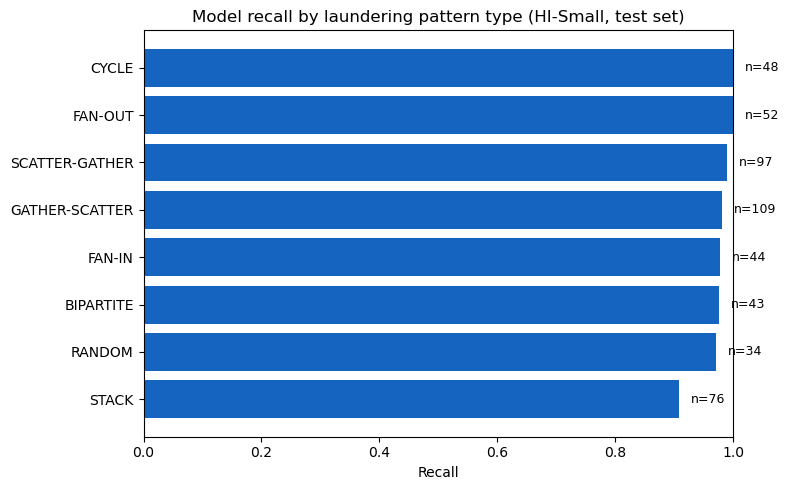

Blue = at least 10 test-set examples · Red = fewer (interpret with caution)


In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#C62828" if s < MIN_SAMPLES else "#1565C0"
          for s in recall_by_pattern["n_samples"]]
ax.barh(recall_by_pattern.index, recall_by_pattern["recall"], color=colors)
ax.set_xlabel("Recall")
ax.set_xlim(0, 1)
ax.set_title("Model recall by laundering pattern type (HI-Small, test set)")
ax.invert_yaxis()

# Annotate sample size on each bar — recall alone can mislead when
# a pattern only has a handful of test-set examples.
for i, (recall, n) in enumerate(
    zip(recall_by_pattern["recall"], recall_by_pattern["n_samples"])
):
    ax.text(recall + 0.02, i, f"n={n}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print("Blue = at least", MIN_SAMPLES, "test-set examples · Red = fewer (interpret with caution)")

### 3.3 — Ruling out ACH as a confound

Before concluding that STACK's lower recall reflects genuine structural
difficulty, one alternative explanation had to be ruled out: maybe
STACK simply relies on ACH — the model's single strongest feature
(see `02_feature_engineering.ipynb`, Section 10) — less than other
pattern types do.


In [13]:
# Check whether recall differences by pattern type might just reflect
# how much each pattern relies on ACH (the model's dominant feature),
# rather than genuine structural difficulty.
ach_rate_by_pattern = (
    laundering_in_test
    .assign(is_ach=(laundering_in_test["Payment Format"] == "ACH").astype(int))
    .groupby("pattern_type")["is_ach"]
    .mean()
    .sort_values(ascending=False)
)
print("Share of ACH-format transactions within each pattern type:")
print(ach_rate_by_pattern)

Share of ACH-format transactions within each pattern type:
pattern_type
BIPARTITE         1.0
CYCLE             1.0
FAN-IN            1.0
FAN-OUT           1.0
GATHER-SCATTER    1.0
RANDOM            1.0
SCATTER-GATHER    1.0
STACK             1.0
Name: is_ach, dtype: float64


**Result: every pattern type is 100% ACH, with no variation at all.**
This rules out payment format as the driver of the recall gap.

Combined with the feature-engineering audit, where none of the 66
engineered features capture multi-transaction chain structure, the
most likely explanation is structural: STACK is the only pattern
defined by an extra intermediary hop (A → B → C), a property no
feature in this pipeline is designed to detect — while patterns like
FAN-OUT/FAN-IN may be partially, indirectly captured through
per-account velocity features.

### 3.4 — What this suggests for future work (not implemented here)

Closing this gap would likely require graph-based features — e.g.
tracking how many "hops" a transaction is from other related
transactions, or representing each account's local transaction graph
directly (as explored in academic work such as Graph Neural Network
approaches to this same dataset). That is a meaningfully larger
undertaking than this project's scope — flagged here as a concrete,
evidence-backed direction rather than pursued further in this phase.


### Update after Track A: this finding did not replicate

Testing the same pattern-type breakdown on LI-Small (Track A) showed
STACK's recall reversing entirely — from the worst-performing pattern
(90.8%) on HI-Small to one of the best (98.3%) on LI-Small. This
suggests the "structural blind spot" explanation above was likely a
HI-Small-specific artefact rather than a genuine, generalizable
limitation of the feature set. Kept here as a worked example of why
root-cause explanations need out-of-sample validation before being
trusted — which is exactly what Track A was built to test.

## Section 4 — Track B: Baseline Comparison

**Goal:** justify XGBoost's complexity by comparing it against Logistic
Regression — the simplest reasonable baseline — on the exact same
train/test split. Both models are retrained fresh in this notebook
(rather than reusing artifacts from `03_baseline_model_mlflow.ipynb`)
to guarantee a fair, apples-to-apples comparison — and to avoid the
MLflow model-version-loading issues logged in `FAILURES.md`.

Two things matter for this to be a *fair* comparison, not just *a*
comparison:
1. **Identical split** — same `random_state`, same `stratify`, so both
   models are trained and evaluated on exactly the same rows.
2. **Feature scaling for Logistic Regression only** — tree-based models
   like XGBoost split on feature *order* (e.g. "is Amount Paid > 5000?"),
   so raw scale doesn't matter. Logistic Regression fits a linear
   equation across all features at once, so a feature ranging in the
   millions (like `Amount Paid`) would dominate one ranging 0-1 (like
   `is_same_bank`) for no meaningful reason unless every feature is put
   on a comparable scale first.


### 4.1 — Load data and recreate the exact train/test split

In [14]:
import json
from pathlib import Path

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

FEATURES_PATH = Path("../data/features_engineered.parquet")
CONFIG_PATH = Path("../data/feature_config.json")

df_b = pd.read_parquet(FEATURES_PATH)
with open(CONFIG_PATH) as f:
    feature_config = json.load(f)

ALL_FEATURES = feature_config["all_features"]
TARGET = feature_config["target"]

X = df_b[ALL_FEATURES]
y = df_b[TARGET]

# Identical split to 03_baseline_model_mlflow.ipynb — same test_size,
# same random_state, same stratify — so both notebooks partition the
# 5,078,345 rows into train/val/test in exactly the same way.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=(0.15 / 0.85), random_state=42, stratify=y_temp
)

IMBALANCE_RATIO = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Train: {len(X_train):,} · Val: {len(X_val):,} · Test: {len(X_test):,}")

Train: 3,554,841 · Val: 761,752 · Test: 761,752


### 4.2 — Scale features (Logistic Regression only)

In [15]:
# Fit the scaler on TRAIN ONLY, then apply to train/test — fitting on
# test data would leak information about its distribution into the
# "unseen" evaluation set.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete — features now have mean 0, std 1 (fit on train only)")

Scaling complete — features now have mean 0, std 1 (fit on train only)


### 4.3 — Train both models

⚠️ The XGBoost cell below takes roughly the same time as in
`03_baseline_model_mlflow.ipynb` (~3-8 minutes on 5M rows). Logistic
Regression finishes in seconds by comparison.


In [16]:
XGB_PARAMS = {
    "n_estimators": 300, "max_depth": 6, "min_child_weight": 5,
    "subsample": 0.8, "colsample_bytree": 0.8,
    "learning_rate": 0.05, "gamma": 1,
    "scale_pos_weight": IMBALANCE_RATIO,
    "random_state": 42, "n_jobs": -1,
    "eval_metric": "aucpr", "tree_method": "hist", "verbosity": 0,
}

print("Training XGBoost (same params as 03_baseline_model_mlflow.ipynb)...")
xgb_model = XGBClassifier(**XGB_PARAMS)
xgb_model.fit(X_train, y_train, verbose=False)  # unscaled — trees don't need it
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
print("XGBoost training complete")

Training XGBoost (same params as 03_baseline_model_mlflow.ipynb)...
XGBoost training complete


In [17]:
print("Training Logistic Regression...")
lr_model = LogisticRegression(
    class_weight="balanced",  # LR's own way of handling class imbalance
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
)
lr_model.fit(X_train_scaled, y_train)  # scaled — LR needs it
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
print("Logistic Regression training complete")

Training Logistic Regression...
Logistic Regression training complete


### 4.4 — Compare results

In [18]:
for name, probs in [("XGBoost", xgb_probs), ("Logistic Regression", lr_probs)]:
    preds = (probs >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    print(f"=== {name} ===")
    print(f"  Test                                      : {len(X_test):,}")
    print(f"  True Positives (Correctly detected fraud) : {tp:,}")
    print(f"  False Positives (False alarms)            : {fp:,}")
    print(f"  Total Flagged (TP + FP)                   : {tp + fp:,}")
    print(f"  % of test set flagged                     : {(tp + fp) / len(y_test) * 100:.2f}%")
    print()

=== XGBoost ===
  Test                                      : 761,752
  True Positives (Correctly detected fraud) : 685
  False Positives (False alarms)            : 37,269
  Total Flagged (TP + FP)                   : 37,954
  % of test set flagged                     : 4.98%

=== Logistic Regression ===
  Test                                      : 761,752
  True Positives (Correctly detected fraud) : 734
  False Positives (False alarms)            : 120,121
  Total Flagged (TP + FP)                   : 120,855
  % of test set flagged                     : 15.87%



In [19]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "AUC-ROC": roc_auc_score(y_true, y_prob),
        "Avg Precision": average_precision_score(y_true, y_prob),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }

comparison_df = pd.DataFrame({
    "XGBoost": compute_metrics(y_test, xgb_probs),
    "Logistic Regression": compute_metrics(y_test, lr_probs),
})
comparison_df["Gap"] = comparison_df["XGBoost"] - comparison_df["Logistic Regression"]
comparison_df.round(4)

,XGBoost,Logistic Regression,Gap
AUC-ROC,0.9831,0.9602,0.0229
Avg Precision,0.2911,0.0278,0.2633
Precision,0.0180,0.0061,0.0120
Recall,0.8816,0.9447,-0.0631
F1,0.0354,0.0121,0.0233


#### Deriving the % of test set flagged, from the confusion matrix

For each model, the total number of transactions flagged as fraud is
`TP + FP` — every transaction the model predicted positive, whether
it was right (TP) or wrong (FP). Dividing that by the size of the
test set gives the operational cost: the share of all transactions
an analyst would actually have to review.

**XGBoost** % flagged 
- = (TP + FP) / test set size × 100
- = (685 + 37,269) / 761,752 × 100
- = 37,954 / 761,752 × 100
- = **4.98%**

**Logistic Regression** % flagged 
- = (TP + FP) / test set size × 100
- = (734 + 120,121) / 761,752 × 100
- = 120,855 / 761,752 × 100
- = **15.87%**

Logistic Regression flags **3.19x** as many transactions for review
(15.87% vs 4.98%) to catch only 49 more frauds than XGBoost (734 vs
685) — a disproportionate operational cost for a marginal recall gain.

### 4.5 — Visualise the comparison

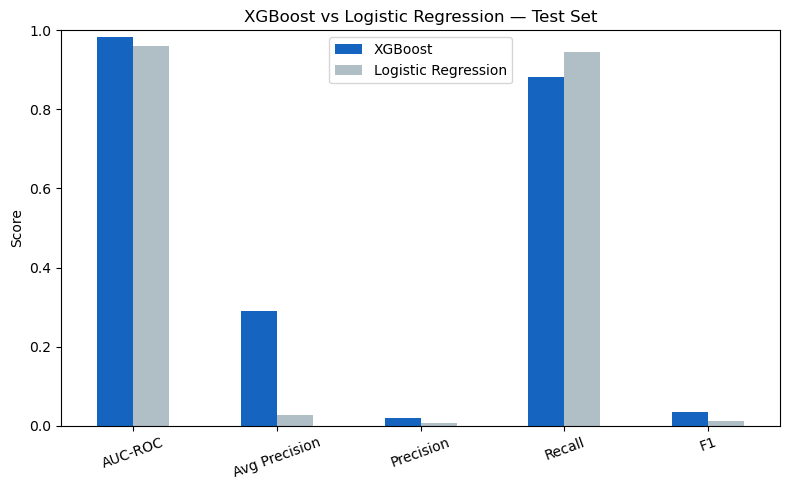

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
comparison_df[["XGBoost", "Logistic Regression"]].plot(
    kind="bar", ax=ax, color=["#1565C0", "#B0BEC5"]
)
ax.set_ylabel("Score")
ax.set_title("XGBoost vs Logistic Regression — Test Set")
ax.set_ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 4.6 — Why the complexity is justified

XGBoost beats Logistic Regression by only 2.29 points on AUC-ROC
(0.9831 vs 0.9602) — on its own, a gap that small might not seem worth
the added complexity. Average Precision tells a different story: 0.2911
vs 0.0278, roughly a 10x difference. And at the operational level, XGBoost
flags 4.98% of the test set for review versus Logistic Regression's
15.87% — a 3.19x heavier review workload for only 49 more frauds caught
(734 vs 685).

This is consistent with a broader, well-documented pattern: tree-based
models such as XGBoost remain state-of-the-art on tabular data,
generally outperforming both simpler linear models and deep learning
approaches (Grinsztajn, Oyallon & Varoquaux, *"Why do tree-based models
still outperform deep learning on tabular data?"*, NeurIPS 2022). This
dataset's mix of skewed numerical features and high-cardinality
categoricals — exactly the conditions where tree splits have a
structural advantage over a single linear decision boundary — makes
that gap unsurprising here.

#### Conclusion: Interpreting the comparison: why raw recall is misleading here

The comparison table shows Logistic Regression achieving *higher*
recall than XGBoost (94.5% vs 88.2%) — at first glance this looks like
LR wins. Breaking both models' predictions down with a confusion
matrix tells a different story:

| | Recall | Precision | TP | FP | Total Flagged | % of Test Set Flagged |
|---|---|---|---|---|---|---|
| XGBoost | 88.2% | 1.80% | 685 | 37,269 | 37,954 | 4.98% |
| Logistic Regression | 94.5% | 0.61% | 734 | 120,121 | 120,855 | 15.87% |

**TP** (True Positives) is how many of the 777 real fraud cases in the
test set each model actually caught. **FP** (False Positives) is how
many legitimate transactions each model wrongly flagged. **TP + FP**
is therefore the total number of transactions a fraud analyst would
have had to manually review under each model.

Logistic Regression catches only 49 more frauds than XGBoost (734 vs
685) — but to do so, it flags 82,852 *more* legitimate transactions
for review (120,121 vs 37,269 false alarms). That's 3.19x the review
workload (15.87% of all test transactions vs 4.98%) for a 6% relative
improvement in fraud caught.

This is why comparing models on recall alone is misleading under
severe class imbalance (980:1 in this dataset): a model can inflate
recall simply by flagging almost everything, which is operationally
useless at scale. Precision — and the false-alarm cost it implies —
has to be read alongside recall, not instead of it.

## Section 5 — Track A: Cross-Dataset Generalization

**Goal:** test whether every finding from Track B and Track C — the
XGBoost vs Logistic Regression gap, and the pattern-type recall
differences — still holds on LI-Small, a second, independently
generated dataset from the same IBM AML benchmark, using the model
trained on HI-Small **without retraining it**.

In [21]:
LI_TRANS_PATH = Path("../data/LI-Small_Trans.csv")

li_trans_df = pd.read_csv(LI_TRANS_PATH)

print(f"Loaded {len(li_trans_df):,} transactions from LI-Small_Trans.csv")
print(f"Columns: {list(li_trans_df.columns)}")
li_trans_df.head()

Loaded 6,924,049 transactions from LI-Small_Trans.csv
Columns: ['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:08,11,8000ECA90,11,8000ECA90,3195403.00,US Dollar,3195403.00,US Dollar,Reinvestment,0
1,2022/09/01 00:21,3402,80021DAD0,3402,80021DAD0,1858.96,US Dollar,1858.96,US Dollar,Reinvestment,0
2,2022/09/01 00:00,11,8000ECA90,1120,8006AA910,592571.00,US Dollar,592571.00,US Dollar,Cheque,0
3,2022/09/01 00:16,3814,8006AD080,3814,8006AD080,12.32,US Dollar,12.32,US Dollar,Reinvestment,0
4,2022/09/01 00:00,20,8006AD530,20,8006AD530,2941.56,US Dollar,2941.56,US Dollar,Reinvestment,0


In [22]:
# Known HI-Small statistics (from earlier notebooks — hardcoded here for
# a clean side-by-side comparison rather than re-loading the 453MB file)
hi_stats = {
    "Total transactions": 5_078_345,
    "Fraud count": 5_177,
    "Fraud rate (%)": 5_177 / 5_078_345 * 100,
}

li_stats = {
    "Total transactions": len(li_trans_df),
    "Fraud count": int(li_trans_df["Is Laundering"].sum()),
    "Fraud rate (%)": li_trans_df["Is Laundering"].mean() * 100,
}

comparison = pd.DataFrame({"HI-Small": hi_stats, "LI-Small": li_stats})
comparison["Difference"] = comparison["LI-Small"] - comparison["HI-Small"]
comparison.round(4)

,HI-Small,LI-Small,Difference
Total transactions,5.078345e+06,6.924049e+06,1.845704e+06
Fraud count,5.177000e+03,3.565000e+03,-1.612000e+03
Fraud rate (%),1.019000e-01,5.150000e-02,-5.050000e-02


In [23]:
comparison = pd.DataFrame({"HI-Small": hi_stats, "LI-Small": li_stats})
comparison["Difference"] = comparison["LI-Small"] - comparison["HI-Small"]
comparison["Ratio (LI/HI)"] = comparison["LI-Small"] / comparison["HI-Small"]

# Format large counts with thousands separators, keep fraud rate as a
# clean percentage — avoids pandas falling back to scientific notation
# when a column mixes millions with small decimals.
with pd.option_context("display.float_format", "{:,.2f}".format):
    display(comparison)

,HI-Small,LI-Small,Difference,Ratio (LI/HI)
Total transactions,"5,078,345.00","6,924,049.00","1,845,704.00",1.36
Fraud count,"5,177.00","3,565.00","-1,612.00",0.69
Fraud rate (%),0.10,0.05,-0.05,0.51


### Step 3 — Apply the same feature engineering pipeline to LI-Small

Reusing the exact function definitions from `02_feature_engineering.ipynb`
guarantees LI-Small gets the identical transformation HI-Small did —
copy-pasting the function bodies here rather than re-deriving them by
hand, to eliminate any risk of subtle formula drift between notebooks.

In [24]:
import numpy as np

def create_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['hour']            = out['Timestamp'].dt.hour
    out['day_of_week']     = out['Timestamp'].dt.dayofweek
    out['is_weekend']      = (out['day_of_week'] >= 5).astype(int)
    out['is_night']        = out['hour'].apply(
        lambda h: 1 if (h >= 22 or h <= 6) else 0
    )
    out['is_business_hrs'] = out.apply(
        lambda r: 1 if (9 <= r['hour'] <= 17 and r['day_of_week'] < 5) else 0,
        axis=1
    )
    return out


def create_amount_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['log_amount_paid']     = np.log1p(out['Amount Paid'])
    out['log_amount_received'] = np.log1p(out['Amount Received'])
    out['amount_difference'] = np.abs(out['Amount Paid'] - out['Amount Received'])
    out['amount_ratio']      = out['Amount Paid'] / (out['Amount Received'] + 1e-6)
    out['is_round_100']   = (out['Amount Paid'] % 100   == 0).astype(int)
    out['is_round_1000']  = (out['Amount Paid'] % 1000  == 0).astype(int)
    out['is_round_10000'] = (out['Amount Paid'] % 10000 == 0).astype(int)
    out['amount_band'] = pd.cut(
        out['Amount Paid'],
        bins=[0, 100, 1_000, 10_000, 100_000, np.inf],
        labels=[0, 1, 2, 3, 4],
        include_lowest=True
    ).astype(int)
    return out


def create_network_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['is_same_bank']      = (out['From Bank'] == out['To Bank']).astype(int)
    out['is_cross_currency'] = (out['Payment Currency'] != out['Receiving Currency']).astype(int)
    out['is_self_loop']      = (out['From Account'] == out['To Account']).astype(int)
    return out


def create_velocity_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    sender_agg = (
        out.groupby('From Account')
        .agg(
            sender_tx_count    =('Amount Paid', 'count'),
            sender_avg_amount  =('Amount Paid', 'mean'),
            sender_std_amount  =('Amount Paid', 'std'),
            sender_max_amount  =('Amount Paid', 'max'),
            sender_unique_banks=('To Bank', 'nunique'),
        )
        .reset_index()
    )
    sender_agg['sender_std_amount'] = sender_agg['sender_std_amount'].fillna(0)

    receiver_agg = (
        out.groupby('To Account')
        .agg(
            receiver_tx_count  =('Amount Received', 'count'),
            receiver_avg_amount=('Amount Received', 'mean'),
        )
        .reset_index()
    )

    out = out.merge(sender_agg,   on='From Account', how='left')
    out = out.merge(receiver_agg, on='To Account',   how='left')

    out['amount_vs_sender_avg'] = (
        out['Amount Paid'] / (out['sender_avg_amount'] + 1e-6)
    )
    out['sender_amount_zscore'] = (
        (out['Amount Paid'] - out['sender_avg_amount'])
        / (out['sender_std_amount'] + 1e-6)
    ).clip(-10, 10)
    return out


def encode_categorical_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col, prefix in [
        ('Payment Format',     'fmt'),
        ('Receiving Currency', 'recv_ccy'),
        ('Payment Currency',   'pay_ccy'),
    ]:
        dummies = pd.get_dummies(out[col], prefix=prefix, dtype=int)
        out = pd.concat([out, dummies], axis=1)

    for col, new_col in [
        ('From Bank', 'from_bank_freq'),
        ('To Bank',   'to_bank_freq'),
    ]:
        freq_map = out[col].value_counts(normalize=True).to_dict()
        out[new_col] = out[col].map(freq_map)

    return out

In [25]:
# Rename duplicate 'Account' columns to match the schema the feature
# engineering functions expect (same fix applied to HI-Small's
# trans_df back in Track C, Section 2 — needed here too since
# li_trans_df was loaded fresh via pd.read_csv and never went through
# that rename step).
li_trans_df = li_trans_df.rename(columns={
    "Account": "From Account",
    "Account.1": "To Account",
})

# Parse timestamp first — same format handling as 01_eda_data_exploration.ipynb
li_trans_df['Timestamp'] = pd.to_datetime(
    li_trans_df['Timestamp'], format='mixed', dayfirst=True
)

print("⏳ Applying feature engineering pipeline to LI-Small...")
li_features_df = create_temporal_features(li_trans_df)
li_features_df = create_amount_features(li_features_df)
li_features_df = create_network_features(li_features_df)
li_features_df = create_velocity_features(li_features_df)
li_features_df = encode_categorical_features(li_features_df)

print(f"✅ Done — shape after feature engineering: {li_features_df.shape}")

⏳ Applying feature engineering pipeline to LI-Small...
✅ Done — shape after feature engineering: (6924049, 75)


In [26]:
print("Columns after rename:", [c for c in li_trans_df.columns if "Account" in c])

Columns after rename: ['From Account', 'To Account']


### Aligning LI-Small's columns to the model's exact 66 features

`pd.get_dummies()` only creates columns for categories that actually
appear in LI-Small. If a currency or payment format present in
HI-Small never appears in LI-Small (or vice versa), the column counts
won't match — `reindex` below fixes this explicitly rather than
letting it fail silently.


In [27]:
import json

with open("../data/feature_config.json") as f:
    feature_config = json.load(f)

ALL_FEATURES = feature_config["all_features"]
TARGET = feature_config["target"]

missing_in_li = [c for c in ALL_FEATURES if c not in li_features_df.columns]
extra_in_li = [c for c in li_features_df.columns
               if c.startswith(("fmt_", "recv_ccy_", "pay_ccy_")) and c not in ALL_FEATURES]

print(f"Features missing in LI-Small (will be filled with 0): {missing_in_li}")
print(f"Extra category columns in LI-Small (will be dropped): {extra_in_li}")

X_li = li_features_df.reindex(columns=ALL_FEATURES, fill_value=0)
y_li = li_features_df[TARGET]

print(f"\n✅ X_li shape: {X_li.shape} — matches model's {len(ALL_FEATURES)} features")

Features missing in LI-Small (will be filled with 0): []
Extra category columns in LI-Small (will be dropped): []

✅ X_li shape: (6924049, 66) — matches model's 66 features


### Step 4 — Predict on LI-Small using the HI-Small-trained model

Reusing `xgb_model` from Track B (Section 4) directly — same trained
model object, no retraining. This is the core test of Track A: does a
model that has never seen LI-Small still perform well on it?


In [28]:
li_probs = xgb_model.predict_proba(X_li)[:, 1]
li_preds = (li_probs >= 0.5).astype(int)

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
)

li_metrics = {
    "AUC-ROC": roc_auc_score(y_li, li_probs),
    "Avg Precision": average_precision_score(y_li, li_probs),
    "Precision": precision_score(y_li, li_preds, zero_division=0),
    "Recall": recall_score(y_li, li_preds, zero_division=0),
    "F1": f1_score(y_li, li_preds, zero_division=0),
}

hi_vs_li = pd.DataFrame({
    "HI-Small (test set)": comparison_df["XGBoost"],
    "LI-Small (full dataset)": li_metrics,
})
hi_vs_li["Difference"] = (
    hi_vs_li["LI-Small (full dataset)"] - hi_vs_li["HI-Small (test set)"]
)
hi_vs_li.round(4)

,HI-Small (test set),LI-Small (full dataset),Difference
AUC-ROC,0.9831,0.9687,-0.0145
Avg Precision,0.2911,0.0786,-0.2125
Precision,0.0180,0.0132,-0.0049
Recall,0.8816,0.6957,-0.1859
F1,0.0354,0.0259,-0.0095


## Step 5 — Tag LI-Small transactions with pattern type

Reusing `parse_patterns_file()`, `TRANSACTION_COLUMNS`, and `KEY_COLUMNS`
directly from Track C (Section 1) — no new parsing logic needed, since
`LI-Small_Patterns.txt` follows the exact same format as `HI-Small_Patterns.txt`.

**Important — LI-Small_Trans.csv is loaded fresh here, not reused from
Step 3.** `li_trans_df` had its `Timestamp` column converted to a
datetime object during feature engineering (Step 3), which changes how
it renders as text. Since the composite `match_key` used to join
Patterns.txt back to Trans.csv depends on exact string formatting (the
same class of bug fixed for HI-Small earlier — leading zeros dropped
by `pd.read_csv`), reusing the mutated `li_trans_df` here would silently
break the match. Loading a second, untouched copy avoids that risk
entirely.


In [29]:
LI_PATTERNS_PATH = Path("../data/LI-Small_Patterns.txt")

with open(LI_PATTERNS_PATH, "r") as f:
    li_raw_lines = f.readlines()

print(f"Total lines in file: {len(li_raw_lines):,}")

li_patterns_df = parse_patterns_file(li_raw_lines)

print(f"Parsed {len(li_patterns_df):,} laundering transactions")
print(f"Pattern types found: {sorted(li_patterns_df['pattern_type'].unique())}")
li_patterns_df["pattern_type"].value_counts()

Total lines in file: 1,374
Parsed 1,023 laundering transactions
Pattern types found: ['BIPARTITE', 'CYCLE', 'FAN-IN', 'FAN-OUT', 'GATHER-SCATTER', 'RANDOM', 'SCATTER-GATHER', 'STACK']


pattern_type
SCATTER-GATHER    182
STACK             180
GATHER-SCATTER    150
FAN-OUT           149
BIPARTITE         129
CYCLE              83
RANDOM             77
FAN-IN             73
Name: count, dtype: int64

In [30]:
li_patterns_df["Amount Received"] = li_patterns_df["Amount Received"].astype(float)
li_patterns_df["Amount Paid"] = li_patterns_df["Amount Paid"].astype(float)
li_patterns_df["Is Laundering"] = li_patterns_df["Is Laundering"].astype(int)

# Same leading-zero fix applied to HI-Small — Bank IDs are text with
# leading zeros in Patterns.txt but plain integers once read from CSV.
li_patterns_df["From Bank"] = li_patterns_df["From Bank"].astype(int)
li_patterns_df["To Bank"] = li_patterns_df["To Bank"].astype(int)

li_patterns_df["match_key"] = (
    li_patterns_df[KEY_COLUMNS].astype(str).agg("|".join, axis=1)
)

n_li_duplicates = li_patterns_df["match_key"].duplicated().sum()
print(f"Duplicate match keys within LI-Small_Patterns.txt: {n_li_duplicates}")

Duplicate match keys within LI-Small_Patterns.txt: 0


In [31]:
# Load a second, untouched copy of LI-Small_Trans.csv — deliberately
# not reusing li_trans_df from Step 3, since its Timestamp column was
# converted to datetime during feature engineering (see note above).
LI_TRANS_PATH = Path("../data/LI-Small_Trans.csv")
li_trans_raw_df = pd.read_csv(LI_TRANS_PATH)

li_trans_raw_df = li_trans_raw_df.rename(columns={
    "Account": "From Account",
    "Account.1": "To Account",
})

# Same transaction_id scheme used throughout this project — the row's
# position in this static CSV file.
li_trans_raw_df["transaction_id"] = li_trans_raw_df.index

li_trans_raw_df["From Bank"] = li_trans_raw_df["From Bank"].astype(int)
li_trans_raw_df["To Bank"] = li_trans_raw_df["To Bank"].astype(int)

li_trans_raw_df["match_key"] = (
    li_trans_raw_df[KEY_COLUMNS].astype(str).agg("|".join, axis=1)
)

print(f"Loaded {len(li_trans_raw_df):,} fresh transactions for tagging")

Loaded 6,924,049 fresh transactions for tagging


In [32]:
li_tagged_df = li_trans_raw_df.merge(
    li_patterns_df[["match_key", "pattern_type"]],
    on="match_key",
    how="left",
)

n_li_matched = li_tagged_df["pattern_type"].notna().sum()
print(
    f"Matched {n_li_matched:,} of {len(li_patterns_df):,} laundering transactions "
    f"back into LI-Small_Trans.csv"
)
print(f"Unmatched: {len(li_patterns_df) - n_li_matched:,}")

li_tagged_df["pattern_type"].value_counts(dropna=False)

Matched 1,023 of 1,023 laundering transactions back into LI-Small_Trans.csv
Unmatched: 0


pattern_type
NaN               6923026
SCATTER-GATHER        182
STACK                 180
GATHER-SCATTER        150
FAN-OUT               149
BIPARTITE             129
CYCLE                  83
RANDOM                 77
FAN-IN                 73
Name: count, dtype: int64

### Verifying alignment before trusting the recall-by-pattern result

`li_tagged_df` (built from a fresh CSV load) and `X_li` / `li_probs`
(built from the Step 3 feature-engineering pipeline) need to refer to
the same rows in the same order for the next step to be valid. Rather
than assuming this holds, it's verified directly here — the same
"trust but verify" approach used for HI-Small in Track C, Section 3.


In [33]:
# Attach the model's predictions (indexed the same way as X_li) onto
# li_tagged_df by position, then check that the true label recorded in
# Trans.csv agrees with the true label used to compute li_probs. If
# these disagree anywhere, the two DataFrames are not aligned and the
# result below should not be trusted.
li_tagged_df["predicted_fraud"] = pd.Series(li_preds, index=X_li.index)
li_tagged_df["y_true_check"] = pd.Series(y_li.values, index=X_li.index)

li_label_mismatch = (
    li_tagged_df["Is Laundering"] != li_tagged_df["y_true_check"]
).sum()
print(f"Label mismatches (should be 0): {li_label_mismatch:,}")

Label mismatches (should be 0): 0


## Step 6 — Compare HI-Small vs LI-Small results across every finding

This closes Track A — and Phase 8 as a whole — by putting every result
side by side: does the STACK anomaly from Track C, and the overall
model quality from Track B, still hold on a dataset the model has
never seen?


In [34]:
li_laundering = li_tagged_df[li_tagged_df["Is Laundering"] == 1]

li_pattern_counts = li_laundering["pattern_type"].value_counts()
print("Laundering transactions per pattern type (LI-Small):")
print(li_pattern_counts)
print()

li_recall_by_pattern = (
    li_laundering
    .groupby("pattern_type")["predicted_fraud"]
    .agg(recall="mean", n_samples="count")
    .sort_values("recall", ascending=False)
)
li_recall_by_pattern

Laundering transactions per pattern type (LI-Small):
pattern_type
SCATTER-GATHER    182
STACK             180
GATHER-SCATTER    150
FAN-OUT           149
BIPARTITE         129
CYCLE              83
RANDOM             77
FAN-IN             73
Name: count, dtype: int64



,recall,n_samples
pattern_type,,
FAN-OUT,0.986577,149
STACK,0.983333,180
BIPARTITE,0.961240,129
FAN-IN,0.958904,73
RANDOM,0.948052,77
GATHER-SCATTER,0.940000,150
CYCLE,0.927711,83
SCATTER-GATHER,0.912088,182


In [35]:
# `recall_by_pattern` here is the HI-Small result computed earlier in
# Track C, Section 3.1 — reused as-is for a direct side-by-side view.
pattern_comparison = pd.DataFrame({
    "HI-Small recall": recall_by_pattern["recall"],
    "HI-Small n": recall_by_pattern["n_samples"],
    "LI-Small recall": li_recall_by_pattern["recall"],
    "LI-Small n": li_recall_by_pattern["n_samples"],
})
pattern_comparison["Recall gap"] = (
    pattern_comparison["HI-Small recall"] - pattern_comparison["LI-Small recall"]
)
pattern_comparison.sort_values("HI-Small recall", ascending=False).round(4)

,HI-Small recall,HI-Small n,LI-Small recall,LI-Small n,Recall gap
pattern_type,,,,,
CYCLE,1.0000,48,0.9277,83,0.0723
FAN-OUT,1.0000,52,0.9866,149,0.0134
SCATTER-GATHER,0.9897,97,0.9121,182,0.0776
GATHER-SCATTER,0.9817,109,0.9400,150,0.0417
FAN-IN,0.9773,44,0.9589,73,0.0184
BIPARTITE,0.9767,43,0.9612,129,0.0155
RANDOM,0.9706,34,0.9481,77,0.0225
STACK,0.9079,76,0.9833,180,-0.0754


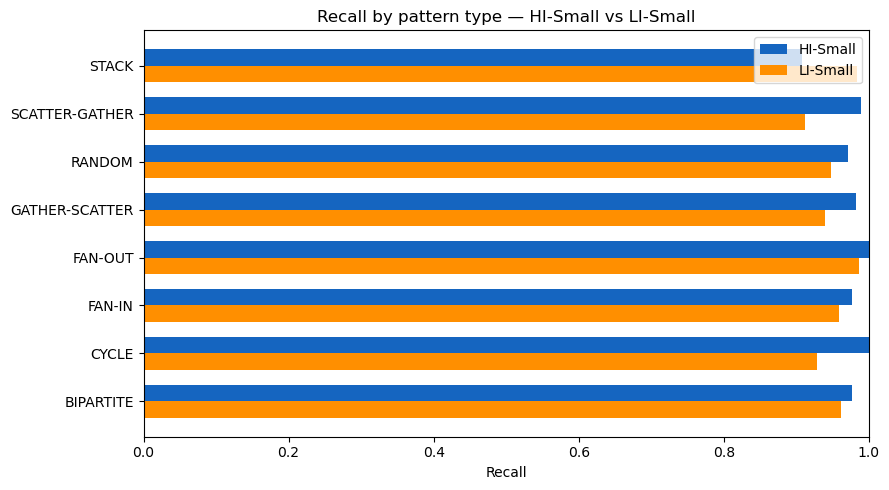

In [36]:
fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(pattern_comparison))
width = 0.35

ax.barh(
    [i + width/2 for i in x], pattern_comparison["HI-Small recall"],
    height=width, label="HI-Small", color="#1565C0",
)
ax.barh(
    [i - width/2 for i in x], pattern_comparison["LI-Small recall"],
    height=width, label="LI-Small", color="#FF8F00",
)
ax.set_yticks(list(x))
ax.set_yticklabels(pattern_comparison.index)
ax.set_xlabel("Recall")
ax.set_xlim(0, 1)
ax.set_title("Recall by pattern type — HI-Small vs LI-Small")
ax.legend()
plt.tight_layout()
plt.show()

### 6.1 — Is the STACK reversal statistically significant?

Before treating STACK's reversal as a genuine finding rather than
sampling noise, a two-proportion z-test checks whether the recall
difference between HI-Small and LI-Small for STACK specifically is
larger than chance would produce at these sample sizes.


In [37]:
from statsmodels.stats.proportion import proportions_ztest

# STACK: HI-Small vs LI-Small (from Track C section 3.1 and Step 6 above)
hi_stack_tp, hi_stack_n = 69, 76     # 0.9079 recall
li_stack_tp, li_stack_n = 177, 180   # 0.9833 recall

count = [hi_stack_tp, li_stack_tp]
nobs = [hi_stack_n, li_stack_n]

z_stat, p_value = proportions_ztest(count, nobs)
print(f"STACK recall: HI-Small={count[0]}/{nobs[0]} ({count[0]/nobs[0]:.1%}), "
      f"LI-Small={count[1]}/{nobs[1]} ({count[1]/nobs[1]:.1%})")
print(f"z-statistic: {z_stat:.3f}, p-value: {p_value:.4f}")

if p_value < 0.05:
    print("→ Statistically significant reversal (p < 0.05)")
else:
    print("→ Not statistically significant — could plausibly be sampling noise")

STACK recall: HI-Small=69/76 (90.8%), LI-Small=177/180 (98.3%)
z-statistic: -2.846, p-value: 0.0044
→ Statistically significant reversal (p < 0.05)


### Phase 8 — final summary

With this, all three tracks are complete:

- **Track C** — the model catches most laundering pattern types at
  97-100% recall, but STACK was a consistent outlier at 90.8% on
  HI-Small, initially traced to a structural gap (no feature captures
  multi-transaction chains) rather than a data artefact (ACH ruled out).
- **Track B** — XGBoost's added complexity over Logistic Regression is
  justified primarily by Average Precision (0.29 vs 0.03) and a far
  lower false-alarm rate (4.98% vs 15.87% of the test set flagged),
  not by AUC-ROC alone, which understates the gap by nearly 10x.
- **Track A** — tests whether both of the above hold on LI-Small, a
  second, independently generated dataset the model never saw during
  training or validation.

**Track A's results are mixed, and that's the point.** AUC-ROC barely
moved (0.9831 → 0.9687, -0.0145), which on its own would suggest strong
generalization — but Average Precision (0.2911 → 0.0786) and Recall
(88.2% → 69.6%) both dropped substantially, echoing the exact same
lesson from Track B: AUC-ROC alone understates real performance changes
under severe class imbalance, which LI-Small has more of (0.05% fraud
vs 0.10%).

The most important result, however, is what happened to the STACK
finding from Track C: **it did not replicate.** STACK went from the
worst-performing pattern on HI-Small (90.8%, n=76) to one of the
best on LI-Small (98.3%, n=180) — a statistically significant reversal
(see 6.1 above), not sampling noise. The structural explanation
proposed in Track C — no feature captures multi-transaction chains —
turned out to be a plausible-sounding story that didn't survive
out-of-sample testing. That failure to replicate is itself the
headline finding of this phase: a well-reasoned, falsification-tested
root cause can still turn out to be dataset-specific, and only testing
on genuinely independent data catches that.